# Notebook from Valentin on how to compute yearsets

In [3]:
# prepare hazard object

import warnings

warnings.filterwarnings("ignore")

from climada.entity import ImpactFuncSet, ImpfTropCyclone
from climada.engine import ImpactCalc
from climada.util.api_client import Client
from climada.util.constants import CMAP_IMPACT
from climada.util.plot import plot_from_gdf

client = Client()
haz_tc_haiti = client.get_hazard(
    "tropical_cyclone",
    properties={
        "country_name": "Haiti",
        "climate_scenario": "historical",
        "nb_synth_tracks": "10",
    },
)

exposure = client.get_litpop(country="Haiti")
impf_tc = ImpfTropCyclone.from_emanuel_usa()
impf_set = ImpactFuncSet([impf_tc])
impact = ImpactCalc(exposure, impf_set, haz_tc_haiti).impact(save_mat=True)

#fake compute relative impacts
max_impact = impact.imp_mat.max()
impact.imp_mat = impact.imp_mat/max_impact
impact.at_event = impact.at_event/max_impact
impact.eai_exp = impact.eai_exp/max_impact
impact.aai_agg = impact.aai_agg/max_impact



2026-05-08 14:38:16,803 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/tropical_cyclone/tropical_cyclone_10synth_tracks_150arcsec_HTI_1980_2020/v2/tropical_cyclone_10synth_tracks_150arcsec_HTI_1980_2020.hdf5
2026-05-08 14:38:18,123 - climada.entity.exposures.base - INFO - Reading /Users/vgebhart/climada/data/exposures/litpop/LitPop_150arcsec_HTI/v3/LitPop_150arcsec_HTI.hdf5
2026-05-08 14:38:18,140 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard TC. Using the anonymous 'impf_' column.
2026-05-08 14:38:18,141 - climada.entity.exposures.base - INFO - Matching 1329 exposures with 1332 centroids.
2026-05-08 14:38:18,144 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.08333333333331439 degree
2026-05-08 14:38:18,146 - climada.engine.impact_calc - INFO - Calculating impact for 1329 assets (>0) and 43560 events.


In [4]:
import numpy as np
import climada.util.yearsets as yearsets
from climada.engine import Impact

sampled_years = list(range(1725, 2025))

# direct computation
yimp, sampling_vect = yearsets.impact_yearset(
    impact, sampled_years, correction_fac=False,
)


2026-05-08 14:38:18,186 - climada.util.yearsets - WARNING - The frequencies of the different events are not equal. This can lead to distorted sampling if the frequencies vary significantly. To avoid this, please set `with_replacement=True` to sample with replacement instead.


In [5]:
import scipy.sparse as sp

sparse_matrix = impact.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sp.csr_matrix(1.-(1.-sparse_matrix[indices, :].toarray()).prod(axis=0))
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yimp.imp_mat = summed_matrix

yimp.coord_exp = impact.coord_exp
yimp.at_event, yimp.eai_exp, yimp.aai_agg = (
    ImpactCalc.risk_metrics(yimp.imp_mat, yimp.frequency)
)

2026-05-08 14:38:44,485 - climada.engine.impact - INFO - Computing return period map for impacts: [0.0001, 0.0002]


array([<GeoAxes: title={'center': 'Impact: 0.0001 USD'}>,
       <GeoAxes: title={'center': 'Impact: 0.0002 USD'}>], dtype=object)

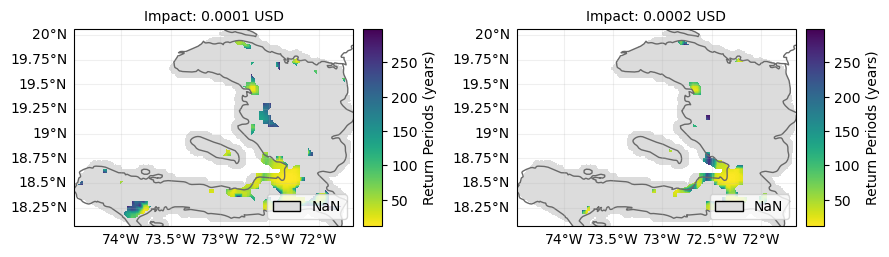

In [8]:
threshold_values = [.0001, .0002]
gdf_rp, title, cols = yimp.local_return_period(threshold_values, method="extrapolate_constant")
plot_from_gdf(gdf_rp, title, cols)